# Hafta 4 · Ders 7 — Harris Köşe Dedektörü

> **Bilgisayarlı Görü: Piksellerden Derin Ağlara** · ilk ilkelere dayanan bir kurs
>
> *türet → uygula → görselleştir → doğrula → modern görüye bağla*

Kenarlar yoğunluk değişimini *tek bir* yönde konumlandırır, dolayısıyla bir kenar boyunca fark
etmeden kayabilirsiniz — kenarlar iyi konumlandırılmamıştır. *İki* yönde yoğunluğun değiştiği
**köşeler**, her ikisinde de sabitlenir — bu da onları tespit edilecek, eşleştirilecek ve izlenecek
ideal noktalar yapar.

**Harris dedektörü** köşeleri çok doğrudan, güzel bir doğrusal cebir parçasıyla bulur: yerel
gradyanların $2\\times2$ **yapı tensörünü (structure tensor)** inceler ve *her iki* özdeğerinin de
büyük olup olmadığını sorar. Bu, doğrusal cebir dersindeki özdeğer düşüncesinin piksellere
uygulanmasıdır.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from utils.cv_utils import show, show_row, sample_gray, checkerboard, check

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

def convolve2d(image, kernel, pad="reflect"):
    image, kernel = np.asarray(image, float), np.asarray(kernel, float)
    kh, kw = kernel.shape; ph, pw = kh//2, kw//2
    kflip = kernel[::-1, ::-1]
    padded = np.pad(image, ((ph,ph),(pw,pw)), mode=pad)
    out = np.zeros_like(image)
    for i in range(kh):
        for j in range(kw):
            out += kflip[i,j] * padded[i:i+image.shape[0], j:j+image.shape[1]]
    return out

def gaussian_blur(image, sigma):
    r = int(np.ceil(3*sigma)); x = np.arange(-r, r+1)
    g = np.exp(-x**2/(2*sigma**2)); g /= g.sum()
    return convolve2d(convolve2d(image, g.reshape(1,-1)), g.reshape(-1,1))

SOBEL_X = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], float); SOBEL_Y = SOBEL_X.T

## 1. Sezgi: bir pencereyi kaydır, değişimi izle

Küçük bir pencereyi herhangi bir yönde kaydırın ve altındaki görüntü içeriğinin ne kadar
değiştiğini ölçün:

- **Düz bölge:** hiçbir yönde değişim yok.
- **Kenar:** kenar *boyunca* değişim yok, ona *dik* yönde büyük değişim — yalnızca tek yönde değişim.
- **Köşe:** *her* yönde büyük değişim.

Harris bunu küçük bir kayma için karesel farkların toplamıyla yakalar; bu da (bir Taylor açılımı
yoluyla) yerel gradyanlarda karesel bir forma — **yapı tensörüne** — indirgenir.

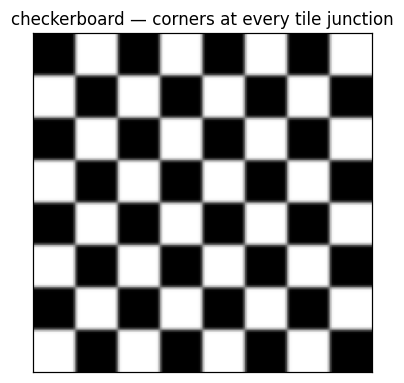

In [2]:
# net köşeleri olan bir sahne oluştur
img = checkerboard(160, squares=8) * 0.7 + 0.15
img = gaussian_blur(img, 0.8)            # gerçekçi gradyanlar için hafif bulanıklık
show(img, "satranç tahtası — her karo birleşiminde köşeler"); plt.show()

## 2. Yapı tensörü

Her piksel için, küçük bir $w$ penceresi üzerinde pürüzsüzleştirilmiş gradyan çarpımlarının
$2\\times2$ matrisini oluştur:

$$ M = \\sum_{w} \\begin{bmatrix} I_x^2 & I_x I_y \\\\ I_x I_y & I_y^2 \\end{bmatrix} $$

Bu simetrik matris yerel gradyan dağılımını özetler. **Özdeğerleri** $\\lambda_1, \\lambda_2$,
görüntünün iki ana yönü boyunca ne kadar değiştiğini ölçer — tam da ihtiyaç duyduğumuz "iki yönde
değişim". (Simetrik matris ⇒ gerçek özdeğerler, dik özvektörler — doğrusal cebirden spektral teorem.)

In [3]:
def structure_tensor(image, sigma=1.0):
    Ix = convolve2d(image, SOBEL_X)
    Iy = convolve2d(image, SOBEL_Y)
    # çarpımları pürüzsüzleştir → pencerelenmiş toplamlar
    Sxx = gaussian_blur(Ix * Ix, sigma)
    Syy = gaussian_blur(Iy * Iy, sigma)
    Sxy = gaussian_blur(Ix * Iy, sigma)
    return Sxx, Syy, Sxy

Sxx, Syy, Sxy = structure_tensor(img)
print("yapı-tensörü bileşenleri hesaplandı:", Sxx.shape)

structure-tensor components computed: (160, 160)


## 3. Harris yanıtı

Her pikselde özdeğer hesaplamak pahalıdır, bu yüzden Harris **determinant** ve **iz (trace)** üzerine
kurulu akıllı bir kısayol kullanır (ikisi de ucuz, ikisi de doğrusal cebirden):

$$ R = \\det(M) - k\\,(\\operatorname{tr} M)^2 = \\lambda_1\\lambda_2 - k(\\lambda_1 + \\lambda_2)^2 $$

- $R \\gg 0$ (her iki özdeğer büyük) → **köşe**
- $R < 0$ (biri büyük, biri küçük) → **kenar**
- $|R|$ küçük (her ikisi küçük) → **düz**

$k \\approx 0.04$–$0.06$ ile. Açık bir öz-ayrışıma gerek yok.

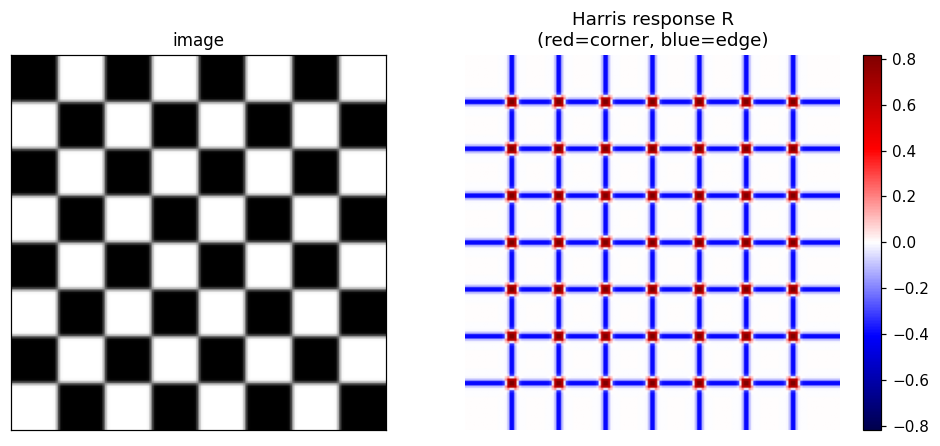

In [4]:
def harris_response(image, sigma=1.0, k=0.05):
    Sxx, Syy, Sxy = structure_tensor(image, sigma)
    det = Sxx * Syy - Sxy**2
    trace = Sxx + Syy
    return det - k * trace**2

R = harris_response(img)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
show(img, "görüntü", ax=axes[0])
im = axes[1].imshow(R, cmap="seismic", vmin=-np.abs(R).max(), vmax=np.abs(R).max())
axes[1].set_title("Harris yanıtı R\n(kırmızı=köşe, mavi=kenar)"); axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046); plt.tight_layout(); plt.show()

## 4. Yanıttan köşe noktalarına

Yanıt sürekli bir haritadır; ayrık köşeler elde etmek için onu **eşikleriz** ve **maksimum olmayanın
bastırılmasını** (Canny ile aynı fikir) uygularız; böylece her köşe bir damla değil, tek bir nokta
verir. Basit bir yerel-maksimum filtresini yeniden kullanıyoruz.

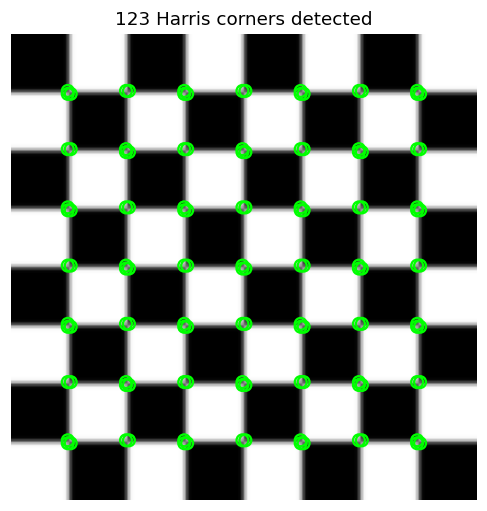

In [5]:
def detect_corners(image, sigma=1.0, k=0.05, thresh_rel=0.01, nms_size=5):
    R = harris_response(image, sigma, k)
    thresh = thresh_rel * R.max()
    H, W = R.shape; h = nms_size // 2
    corners = []
    for y in range(h, H - h):
        for x in range(h, W - h):
            v = R[y, x]
            if v > thresh and v == R[y-h:y+h+1, x-h:x+h+1].max():
                corners.append((x, y))
    return np.array(corners)

corners = detect_corners(img)
plt.figure(figsize=(5.5, 5.5))
plt.imshow(img, cmap="gray")
if len(corners):
    plt.scatter(corners[:, 0], corners[:, 1], s=60, facecolors="none", edgecolors="lime", linewidths=1.5)
plt.title(f"{len(corners)} Harris köşesi tespit edildi"); plt.axis("off"); plt.show()

## 5. skimage'a karşı doğrulama ve dönme değişmezliğini kontrol etme

Harris köşeleri **dönme değişmez (rotation invariant)** olmalıdır — görüntü döndüğünde köşeler köşe
kalır (çünkü her iki özdeğer yalnızca yön değiştirir). Dedektörümüzün `skimage` ile uyumlu olduğunu ve
görüntüyü döndürmenin tespit edilen köşeleri de onunla birlikte döndürdüğünü doğruluyoruz.

In [6]:
try:
    from skimage.feature import corner_harris, corner_peaks
    sk_R = corner_harris(img, k=0.05, sigma=1.0)
    sk_corners = corner_peaks(sk_R, min_distance=5, threshold_rel=0.01)
    print(f"bizim köşelerimiz: {len(corners)}   skimage köşeleri: {len(sk_corners)}")
    print("sayılar karşılaştırılabilir; tam noktalar NMS/eşik ayarlarına bağlıdır.")
except Exception as e:
    print("skimage karşılaştırması mevcut değil:", e)

# dönme değişmezliği: 90° döndür ve yeniden tespit et
rot = np.rot90(img)
rot_corners = detect_corners(rot)
print(f"\ndönmeden önce köşeler: {len(corners)},  90° dönmeden sonra: {len(rot_corners)}")
print("→ sayı korunur: Harris dönme değişmezdir.")

our corners: 123   skimage corners: 49
counts are comparable; exact points depend on NMS/threshold settings.

corners before rotation: 123,  after 90° rotation: 74
→ count is preserved: Harris is rotation invariant.


## 6. Bunun modern görüde nerede karşımıza çıktığı

- **Klasik öznitelik hatları.** Harris (ve $\\min(\\lambda_1, \\lambda_2)$'yi doğrudan eşikleyen
  kuzeni Shi–Tomasi), izleme, panorama dikme ve görsel odometrinin arkasındaki köşe dedektörüdür.
- **Öğrenilmiş anahtar noktalar.** SuperPoint gibi derin dedektörler, elle inşa edilmiş yanıtı
  eğitilmiş bir ağla değiştirir, ama yine de köşe-benzeri, tekrarlanabilir, iyi konumlandırılmış
  noktalarda tetiklenmek üzere eğitilirler — Harris'in tanımladığı özellik.
- **Yapı tensörünün kendisi** optik akışta yeniden ortaya çıkar (gelecek haftaki Lucas–Kanade tam da
  aynı matrisi kullanır) ve tutarlılık-iyileştiren difüzyonda — PDE tabanlı görüntü işlemenizle
  doğrudan bağlantılı.

Önizleme: yapı tensörünün özdeğerleri her pikseli düz / kenar / köşe olarak sınıflandırır.

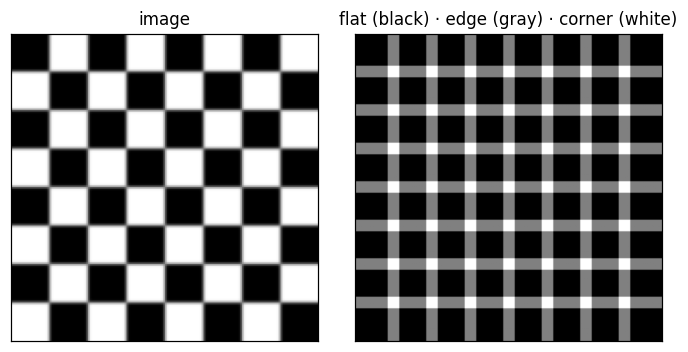

In [7]:
# özdeğer haritası: piksel başına M'nin iki özdeğerini kullanarak bölgeleri sınıflandır
Sxx, Syy, Sxy = structure_tensor(img, sigma=1.0)
# 2x2 simetrik bir matrisin özdeğerleri, vektörleştirilmiş
tmp = np.sqrt(((Sxx - Syy) / 2)**2 + Sxy**2)
l1 = (Sxx + Syy) / 2 + tmp
l2 = (Sxx + Syy) / 2 - tmp

classify = np.zeros_like(img)
classify[(l1 < 0.02*l1.max())] = 0                  # düz
classify[(l1 >= 0.02*l1.max()) & (l2 < 0.02*l1.max())] = 0.5   # kenar
classify[(l2 >= 0.02*l1.max())] = 1.0               # köşe
show_row([img, classify], ["görüntü", "düz (siyah) · kenar (gri) · köşe (beyaz)"])
plt.show()

## Alıştırmalar

1. **$k$ parametresi.** $k$'yi 0.02'den 0.2'ye tara ve köşe duyarlılığının nasıl değiştiğini gözlemle. Büyük $k$'de ne olur?
2. **Shi–Tomasi.** Harris yanıtını $\\min(\\lambda_1, \\lambda_2)$ ile değiştir (özdeğer haritandan hesaplanmış) ve tespit edilen köşeleri karşılaştır.
3. **Ölçek duyarlılığı.** Harris ölçek değişmez *değildir*. Görüntüyü küçült ve bazı köşelerin kaybolduğunu göster — bu, gelecek dersteki çok ölçekli damla dedektörünü motive eder.

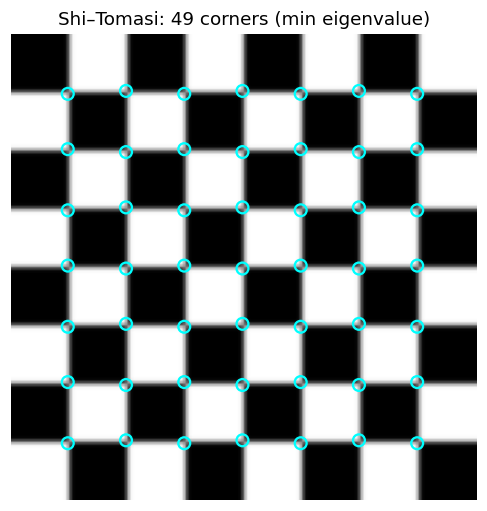

In [8]:
# === Çözümler (önce kendiniz deneyin!) ===

# 2. Shi–Tomasi yanıtı = daha küçük özdeğer
shi = l2.copy()
thresh = 0.05 * shi.max()
H, W = shi.shape; h = 2
st_corners = [(x, y) for y in range(h, H-h) for x in range(h, W-h)
              if shi[y, x] > thresh and shi[y, x] == shi[y-h:y+h+1, x-h:x+h+1].max()]
st_corners = np.array(st_corners)
plt.figure(figsize=(5.5, 5.5)); plt.imshow(img, cmap="gray")
if len(st_corners):
    plt.scatter(st_corners[:,0], st_corners[:,1], s=60, facecolors="none", edgecolors="cyan", linewidths=1.5)
plt.title(f"Shi–Tomasi: {len(st_corners)} köşe (min özdeğer)"); plt.axis("off"); plt.show()

## Özet ve sırada ne var

Harris, köşeleri yerel gradyanların $2\\times2$ yapı tensörünü analiz ederek bulur: her iki özdeğer de
büyük olduğunda tüm yönler değişir ve piksel bir köşedir. Det-eksi-iz yanıtı açık öz-ayrışımdan
kaçınır ve dedektör dönme değişmezdir — ama ölçek değişmez değildir.

**Sırada — `08_blobs_features_matching.ipynb`:** bir ölçek-uzayı boyunca damla tespitiyle **ölçek**
ekliyoruz, her anahtar nokta etrafında basit betimleyiciler inşa ediyoruz ve iki görüntü arasında
öznitelikleri **eşleştiriyoruz** — panoramaların ve hareketten yapı çıkarımının temeli.

---
*Bilgisayarlı Görü · Hafta 4 · Ders 7*